# TraCE-ST: tracing a prescribed multivariate causal pathway

This self-contained notebook introduces TraCE-ST with a controlled system whose causal structure is known by construction. Two spatially coherent anomalies, `A` and `C`, move along prescribed paths and produce a lagged response in target variable `B`. We then ask whether TraCE-ST can work backward from the `B` event and recover its causal origins.

TraCE-ST is **Lagrangian-inspired**, but the recovered path is not a physical parcel trajectory. At each step it estimates a local lagged causal graph, groups parents with coherent spatial directions, selects a parent group, and moves the analysis region backward in space and time.

The notebook covers:

1. construction of a noisy multivariate field with prescribed causal parents;
2. deterministic reconstruction of one backward causal trajectory;
3. comparison with the known spatial pathways; and
4. Monte Carlo pathway uncertainty in a small fixed-parameter probabilistic ensemble.

> **Interpretation:** this compact ensemble demonstrates probabilistic pathway sampling; it is not large enough to estimate publication-quality trajectory densities or causal contributions. Parameter sensitivity is a separate analysis in which the Monte Carlo experiment is repeated across physically admissible configurations.

In [31]:
# 1) Setup: imports and local helpers
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

from trace_st.trajectory import run_track

%matplotlib inline
plt.rcParams['figure.figsize'] = (7, 5)


# A Gaussian blob is a simple analogue of a coherent geophysical anomaly.
def gaussian_blob(y2d, x2d, y0, x0, sig_y=6.0, sig_x=10.0, amp=1.0):
    dy = y2d - float(y0)
    dx = x2d - float(x0)
    return amp * np.exp(-0.5 * (dy / sig_y) ** 2 - 0.5 * (dx / sig_x) ** 2)


# Cubic Bezier curves give A and C smooth, exactly known spatial paths.
def bezier_centers(start, control1, control2, end, T):
    u = np.linspace(0.0, 1.0, T)
    p0 = np.asarray(start, dtype=float)
    p1 = np.asarray(control1, dtype=float)
    p2 = np.asarray(control2, dtype=float)
    p3 = np.asarray(end, dtype=float)
    centers = np.zeros((T, 2), dtype=float)
    for i, s in enumerate(u):
        centers[i] = (
            (1 - s) ** 3 * p0
            + 3 * (1 - s) ** 2 * s * p1
            + 3 * (1 - s) * s ** 2 * p2
            + s ** 3 * p3
        )
    return centers


# Spatially smoothed AR(1) noise mimics persistent, coherent background variability.
def make_spatiotemporal_ar1_noise(shape, phi=0.8, sigma=0.1, smooth_sigma_y=1.5, smooth_sigma_x=1.5, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    T, NY, NX = shape
    noise = np.zeros(shape, dtype=np.float32)
    eps0 = rng.normal(0.0, sigma, size=(NY, NX)).astype(np.float32)
    eps0 = gaussian_filter(eps0, sigma=(smooth_sigma_y, smooth_sigma_x), mode="nearest")
    noise[0] = eps0 / np.sqrt(1.0 - phi**2 + 1e-12)
    for t in range(1, T):
        eps = rng.normal(0.0, sigma, size=(NY, NX)).astype(np.float32)
        eps = gaussian_filter(eps, sigma=(smooth_sigma_y, smooth_sigma_x), mode="nearest")
        noise[t] = phi * noise[t - 1] + eps
    return noise


def build_dataarray(var_name, arr, time_coord, ys, xs):
    return xr.DataArray(
        arr[:, None, :, :].astype(np.float32),
        dims=("time", "var", "y", "x"),
        coords={"time": time_coord, "var": [var_name], "y": ys, "x": xs},
        name="synthetic",
    )


def build_multivariate_case(alpha_mix=0.6, T=40, N_inject=8, tau_mix=1, sig_y=10.0, sig_x=10.0, amp_A=1.0, amp_C=1.0, phi_A=0.85, phi_C=0.85, phi_B=0.80, sigma_A=0.10, sigma_C=0.10, sigma_B=0.10, clip_to_positive=True, seed=11):
    time_coord = pd.date_range("2001-01-01", periods=T, freq="D")
    Y_MIN, Y_MAX = 0, 200
    X_MIN, X_MAX = 0, 200
    NY = 121
    NX = 241
    ys = np.linspace(Y_MIN, Y_MAX, NY)
    xs = np.linspace(X_MIN, X_MAX, NX)
    x2d, y2d = np.meshgrid(xs, ys)

    event_y = 100.0
    event_x = 100.0

    centers_A = bezier_centers((145.0, 60.0), (142.0, 95.0), (120.0, 98.0), (event_y, event_x), T=T)
    centers_C = bezier_centers((40.0, 150.0), (75.0, 148.0), (98.0, 118.0), (event_y, event_x), T=T)

    A_clean = np.zeros((T, NY, NX), dtype=np.float32)
    C_clean = np.zeros((T, NY, NX), dtype=np.float32)
    for t in range(T):
        A_clean[t] = gaussian_blob(y2d, x2d, y0=centers_A[t, 0], x0=centers_A[t, 1], sig_y=sig_y, sig_x=sig_x, amp=amp_A).astype(np.float32)
        C_clean[t] = gaussian_blob(y2d, x2d, y0=centers_C[t, 0], x0=centers_C[t, 1], sig_y=sig_y, sig_x=sig_x, amp=amp_C).astype(np.float32)

    rng_A = np.random.default_rng(seed + 0)
    rng_C = np.random.default_rng(seed + 2)
    noise_A = make_spatiotemporal_ar1_noise(A_clean.shape, phi=phi_A, sigma=sigma_A, rng=rng_A)
    noise_C = make_spatiotemporal_ar1_noise(C_clean.shape, phi=phi_C, sigma=sigma_C, rng=rng_C)

    A = A_clean + noise_A
    C = C_clean + noise_C
    if clip_to_positive:
        A = np.clip(A, 0.0, None)
        C = np.clip(C, 0.0, None)

    t0 = T - int(N_inject)
    if t0 < 0:
        raise ValueError("N_inject too large.")
    if t0 - tau_mix < 0:
        raise ValueError("Need t0 - tau_mix >= 0.")

    rng_B = np.random.default_rng(seed + 1)
    noise_B = make_spatiotemporal_ar1_noise((T, NY, NX), phi=phi_B, sigma=sigma_B, rng=rng_B)
    B = noise_B.copy()
    # Ground-truth causal equation during the event-development period:
    # B(t) = alpha_mix*A_clean(t-tau_mix) + (1-alpha_mix)*C_clean(t-tau_mix) + noise.
    for t in range(t0, T):
        B[t] = alpha_mix * A_clean[t - tau_mix] + (1.0 - alpha_mix) * C_clean[t - tau_mix] + noise_B[t]
    if clip_to_positive:
        B = np.clip(B, 0.0, None)

    full_data_A = build_dataarray("A", A, time_coord, ys, xs)
    full_data_B = build_dataarray("B", B, time_coord, ys, xs)
    full_data_C = build_dataarray("C", C, time_coord, ys, xs)
    full_data_run = xr.concat([full_data_A, full_data_B, full_data_C], dim="var")
    full_data_run = full_data_run.rename({"y": "lat", "x": "lon"})

    return {
        "full_data_run": full_data_run,
        "A": A,
        "B": B,
        "C": C,
        "A_clean": A_clean,
        "C_clean": C_clean,
        "centers_A": centers_A,
        "centers_C": centers_C,
        "event": (event_y, event_x),
        "xs": xs,
        "ys": ys,
        "time": time_coord,
        "T": T,
        "date_end": str(time_coord[-1].date()),
    }


def build_base_params():
    return {
        "timeres": "1d",
        "spaceres": 1,
        "box_size": 20,
        "radius": 2,
        "starting_lat": None,
        "starting_lon": None,
        "timewindow": "4d",
        "child_of_interest": 2,
        "n_steps_time": 30,
        "montecarlo": False,
        "beta_softmax": 1.0,
        "eps_dbscan": 0.15,
        "min_samples_dbscan": 2,
        "score_mode": "mean",
        "gamma": 0.5,
        "alpha": 4.0,
        "prefer_sign": "both",
        "winner_summary": "mean",
        "prob_rule": "softmax",
        "cd_method": "granger",
        "cd_kwargs": {
            "lambda_a": 0.5,
            "l1_ratio": 0.4,
            "dependence_threshold": 1e-7,
            "max_iter": 100000,
            "fit_intercept": False,
            "refit_ridge": False,
            "ridge_alpha": 1e-2,
        },
    }


## 2) Generate a canonical multivariate synthetic case

This follows the manuscript's three-variable controlled experiment. Independent Gaussian anomalies propagate in `A` and `C` and converge on the event location. During the final eight time steps, they generate `B` according to

$$B(t) = \alpha_{mix} A(t-\tau) + (1-\alpha_{mix}) C(t-\tau) + \nu_B(t).$$

Here $\alpha_{mix}=0.6$ and $\tau=1$ day, so `A` contributes 60% and `C` 40% to the prescribed signal before noise. All variables contain spatially coherent AR(1) noise. This provides ground truth: a successful analysis should trace `B` into both source families, while individual deterministic tracks may select only one competing branch.

The final `DataArray` uses the interface expected by `run_track`: `(time, var, lat, lon)`.

In [32]:
case = build_multivariate_case(alpha_mix=0.6, T=40, N_inject=8, tau_mix=1, seed=11)
print("full_data dims:", case["full_data_run"].dims)
print("Variables:", case["full_data_run"].coords["var"].values)
print("Date range:", case["full_data_run"].time.values[0], "->", case["full_data_run"].time.values[-1])

full_data dims: ('time', 'var', 'lat', 'lon')
Variables: ['A' 'B' 'C']
Date range: 2001-01-01T00:00:00.000000 -> 2001-02-09T00:00:00.000000


## 3) Run one TraCE-ST back-trajectory

The target child is `B` (one-based index `2`) at the convergence point on the final date. For every backward day, TraCE-ST pools local space–time stencils inside the moving analysis box, fits an Elastic-Net Granger model, clusters selected parents by variable, sign, and direction, and shifts the box toward the winning cluster.

This run is deterministic because `montecarlo=False`. It displays one plausible dominant branch; it is not expected to express the prescribed 60:40 mixture by itself. Key scale choices are:

- `timewindow`: samples pooled at each local causal-discovery step;
- `box_size`: spatial region over which local relationships are treated as approximately homogeneous;
- `radius`: largest displacement represented by the one-lag stencil; and
- `n_steps_time`: number of daily steps traced backward.

In [40]:
params = build_base_params()
params["starting_lat"] = float(case["event"][0])
params["starting_lon"] = float(case["event"][1])
params["child_of_interest"] = 2
params["n_steps_time"] = 30
params["timewindow"] = "5d"
params["box_size"] = 30
params["radius"] = 4
params["snap_to_grid"] = False
params["averaging_winners"] = True
params["eps_dbscan"] = 0.15
params["min_samples_dbscan"] = 2
params["score_mode"] = "sum"
params["prob_rule"] = "softmax"
params["beta_softmax"] = 1.0

# return_debug and return_cluster_summaries retain the local evidence used at each step.
out = run_track(case["full_data_run"], params, date_end=case["date_end"], return_debug=True, return_cluster_summaries=True)

print("Trajectory centers:")
for c in out["centers"]:
    print(c)
print("Parents:")
print(out["parents"])

Trajectory centers:
[100.0, 100.0]
[98.88299111567488, 103.04889030237307]
[98.88299111567488, 105.12329465316188]
[98.88299111567488, 107.1938989168664]
[97.82600845459886, 109.91307040318789]
[97.82600845459886, 111.88256549481534]
[97.82600845459886, 113.68934853144107]
[96.72280941094213, 116.30962277469533]
[95.58163907447133, 118.81558157422502]
[94.53449077445502, 121.14790740598404]
[94.53449077445502, 119.7448651902664]
[93.36402383341668, 122.4805748751698]
[92.00409200230033, 124.5022035012554]
[90.82979789882586, 127.01686962730155]
[89.74537026443453, 129.32009753349084]
[88.43990575884595, 129.32009753349084]
[87.23489408810535, 131.76227333470428]
[85.69690356882894, 131.76227333470428]
[84.33895323370075, 133.6645203060173]
[82.92292784323251, 135.63518895240455]
[81.52886109445976, 137.51122050589558]
[79.86367749626596, 137.51122050589558]
[78.45663538523517, 139.33297154337927]
[76.03535255046506, 140.79160374040552]
[74.30843890730979, 142.90716456158248]
[72.542972

## 4) Inspect the first-step causal stencils and cluster choice

At the first iteration, `B` at the event time is the child. M-CaStLe estimates the significant one-lag links from every location in each parent-variable stencil: $A_{t-1} \rightarrow B_t$, $B_{t-1} \rightarrow B_t$, and $C_{t-1} \rightarrow B_t$. The panels below show those three stencils. Each dot is a selected causal parent, its color is the signed Elastic-Net regression coefficient, and the center square is the child location. Black rings mark members of the cluster selected for this trajectory step.

TraCE-ST then chooses one coherent parent group as described in the paper:

1. Parents are separated by **parent variable** and coefficient **sign**.
2. Their offsets are projected onto the unit circle, so DBSCAN groups similar propagation directions rather than similar distances. DBSCAN noise points are retained as singleton clusters.
3. Each cluster is scored from the magnitudes of its causal links. This tutorial uses `score_mode='mean'`, so the score is the mean absolute regression coefficient.
4. Because this single trajectory is deterministic (`montecarlo=False`), the highest-scoring cluster wins. In a probabilistic run, the cluster is sampled using the configured linear or softmax probabilities.
5. The winning parent variable becomes the child at the next backward step. Its spatial displacement is the weighted mean of the winning parents' offsets, with weights $|\beta_i|^{\alpha}$; here $\alpha=4$.

The table and final line report the actual cluster scores, winning parent, and computed $(\Delta\mathrm{lat},\Delta\mathrm{lon})$ for this first iteration.

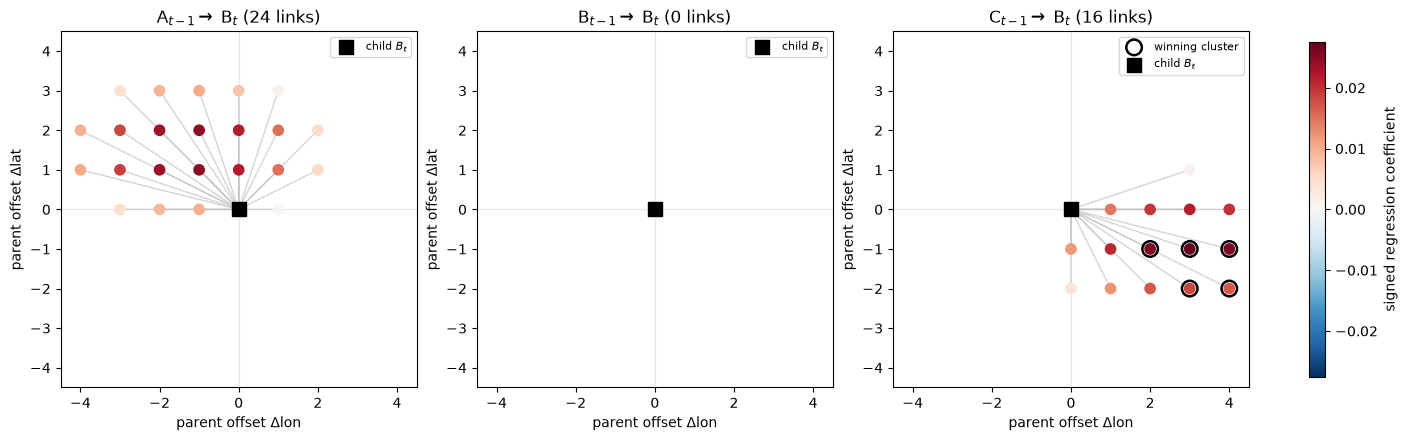

,parent,sign_label,cluster_global,n_members,cluster_score,selected
0,C,pos,13,5,0.114877,True
1,A,pos,4,5,0.081224,False
2,C,pos,10,4,0.075620,False
3,A,pos,0,3,0.052382,False
4,A,pos,2,3,0.051060,False
5,A,pos,1,3,0.044080,False
6,C,pos,12,2,0.037983,False
7,A,pos,6,3,0.024097,False
8,A,pos,5,2,0.020533,False
9,A,pos,3,2,0.016243,False


Selected C -> B, positive cluster 13; computed delta_lat=-1.117, delta_lon=3.049.


In [41]:
# Candidate causal parents retained at the first B_t tracing step.
step_debug = out["debug"][0].copy()
step_summary = out["cluster_summaries"][0].copy()
step_winner = out["winners"][0]
cluster_col = "cluster_global" if "cluster_global" in step_debug.columns else "cluster"

winner_cluster = int(step_winner[cluster_col])
winner_parent = int(str(step_winner["vars"]).split("_")[0].replace("p", ""))
winner_sign = "positive" if float(step_winner["sign"]) > 0 else "negative"
var_names = np.asarray(case["full_data_run"].coords["var"].values)
child_id = int(params["child_of_interest"])

# Use one symmetric coefficient scale so colors are comparable across A, B, and C.
coef_limit = float(step_debug["causal_value_abs"].max())
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), constrained_layout=True)
last_points = None

for parent_id, ax in enumerate(axes, start=1):
    link_name = f"p{parent_id}_c{child_id}"
    links = step_debug.loc[step_debug["vars"] == link_name].copy()
    selected = links[cluster_col] == winner_cluster

    # Offsets are already expressed in physical (lat, lon) units by the trajectory code.
    ax.quiver(
        links["delta_lon"], links["delta_lat"],
        -links["delta_lon"], -links["delta_lat"],
        angles="xy", scale_units="xy", scale=1, color="0.75",
        width=0.004, headwidth=3, alpha=0.65, zorder=1,
    )
    last_points = ax.scatter(
        links["delta_lon"], links["delta_lat"],
        c=links["causal_value"], cmap="RdBu_r",
        vmin=-coef_limit, vmax=coef_limit, s=55, zorder=3,
    )
    if selected.any():
        ax.scatter(
            links.loc[selected, "delta_lon"], links.loc[selected, "delta_lat"],
            s=125, facecolors="none", edgecolors="black",
            linewidths=1.8, label="winning cluster", zorder=4,
        )
    ax.scatter(0, 0, marker="s", s=90, color="black", label=r"child $B_t$", zorder=5)
    ax.axhline(0, color="0.9", linewidth=0.8, zorder=0)
    ax.axvline(0, color="0.9", linewidth=0.8, zorder=0)
    extent = params["radius"] * params["spaceres"] + 0.5 * params["spaceres"]
    ax.set(xlim=(-extent, extent), ylim=(-extent, extent),
           xlabel=r"parent offset $\Delta$lon", ylabel=r"parent offset $\Delta$lat",
           title=rf"{var_names[parent_id - 1]}$_{{t-1}} \rightarrow$ B$_t$ ({len(links)} links)")
    ax.set_aspect("equal")
    ax.legend(loc="upper right", fontsize=8)

fig.colorbar(last_points, ax=axes, shrink=0.78, label="signed regression coefficient")
plt.show()

# Reproduce the cluster score used by the configured selection rule.
if params["score_mode"] == "sum":
    step_summary["cluster_score"] = step_summary["sum_abs_causal"]
elif params["score_mode"] == "mean":
    step_summary["cluster_score"] = step_summary["mean_abs_causal"]
else:
    step_summary["cluster_score"] = (
        step_summary["sum_abs_causal"] / step_summary["n_members"] ** params["gamma"]
    )

summary_cluster_col = "cluster_global" if "cluster_global" in step_summary.columns else "cluster"
step_summary["parent"] = step_summary["parent_p"].map(
    {i: str(name) for i, name in enumerate(var_names, start=1)}
)
step_summary["selected"] = step_summary[summary_cluster_col] == winner_cluster
display(step_summary[["parent", "sign_label", summary_cluster_col, "n_members", "cluster_score", "selected"]]
        .sort_values("cluster_score", ascending=False)
        .reset_index(drop=True))

first_delta = np.asarray(out["centers"][1]) - np.asarray(out["centers"][0])
print(
    f"Selected {var_names[winner_parent - 1]} -> B, {winner_sign} cluster {winner_cluster}; "
    f"computed delta_lat={first_delta[0]:.3f}, delta_lon={first_delta[1]:.3f}."
)

## 5) Compare the reconstruction with the prescribed fields

The dashed curves are known `A` and `C` centers used to generate the data; the blue curve is inferred from the noisy fields alone. Contours show several recent states of each anomaly, so their motion toward the target is visible.

Agreement should be assessed in both **space** (proximity to a prescribed path) and **variable identity** (`out['parents']`). A path can be spatially plausible but assigned to the wrong variable, which would be a causal-attribution error.

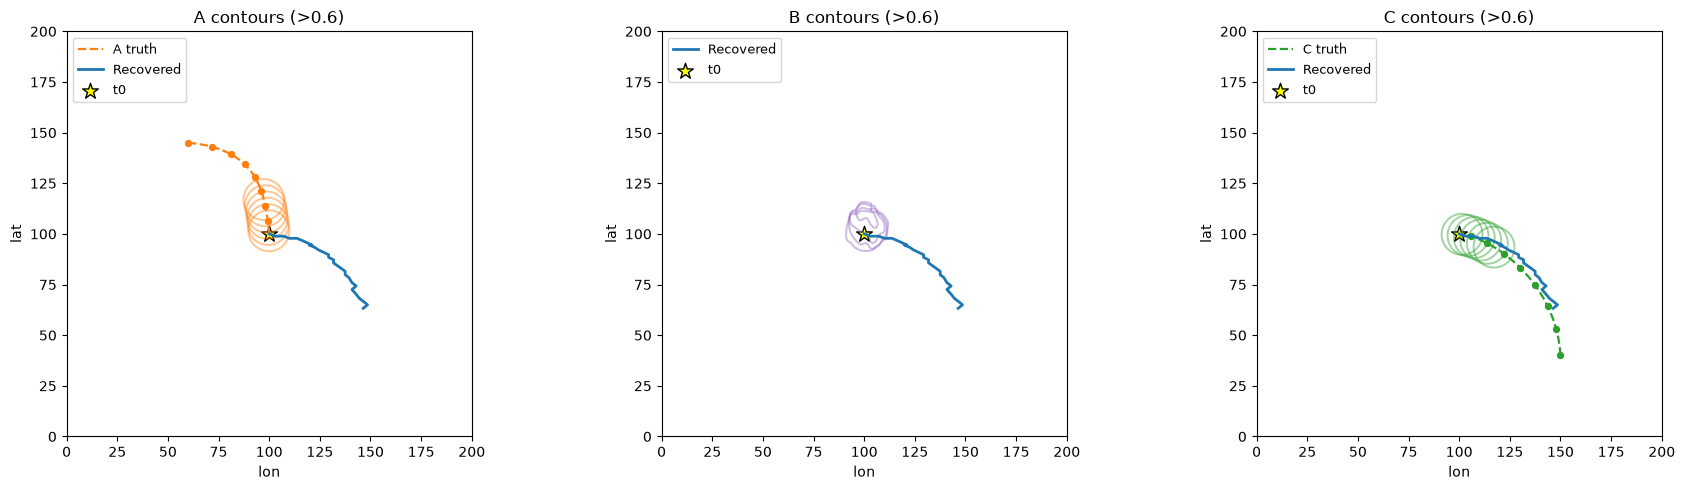

In [42]:
# Field evolution: plot contours > 0.6 over recent times and overlay truth/recovered tracks
truth_A = np.asarray(case['centers_A'])
truth_C = np.asarray(case['centers_C'])
truth_times = np.arange(case['T'] - 12, case['T'], 2)
vars = ['A','B','C']
colors = {'A':'tab:orange','B':'tab:purple','C':'tab:green'}
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, var in zip(axes, vars):
    # try to use cleaned fields if available, otherwise use full_data_run
    key = var + '_clean'
    if key in case:
        data_ts = case[key]  # assumed shape (time,y,x)
    else:
        data_ts = case['full_data_run'].sel(var=var).values
    col = colors[var]
    # draw contours at level 0.6 for recent times
    for t in truth_times:
        try:
            fld = np.asarray(data_ts)[t]
        except Exception:
            fld = data_ts[t]  # fall back if already numpy
        ax.contour(case['xs'], case['ys'], fld, levels=[0.6], colors=[col], linewidths=1.4, alpha=0.45)
    # overlay the truth tracks (A/C) and recovered centers
    if var == 'A':
        ax.plot(truth_A[:,1], truth_A[:,0], '--', color=col, linewidth=1.6, label='A truth')
        ax.scatter(truth_A[::5,1], truth_A[::5,0], s=18, color=col)
    if var == 'C':
        ax.plot(truth_C[:,1], truth_C[:,0], '--', color=col, linewidth=1.6, label='C truth')
        ax.scatter(truth_C[::5,1], truth_C[::5,0], s=18, color=col)
    # recovered trajectory (same on all panels)
    centers = np.asarray(out['centers'])
    ax.plot(centers[:,1], centers[:,0], '-', color='tab:blue', linewidth=2.0, label='Recovered')
    ax.scatter(centers[0,1], centers[0,0], marker='*', s=140, facecolor='yellow', edgecolor='black', label='t0')
    ax.set_title(f'{var} contours (>0.6)')
    ax.set_xlabel('lon')
    ax.set_ylabel('lat')
    ax.set_aspect('equal')
    ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()


## 6) Inspect the moving analysis region

Each blue rectangle represents the analysis region $R$ at a backward step. Within that region and its associated time window, M-CaStLe assumes approximate spatial and temporal stationarity. The region translates according to the causal-strength-weighted displacement of the selected parent cluster; it does not deform or follow a velocity field.

The star marks the target at $t_0$, and the white square marks the oldest reconstructed point. Parent IDs are converted back to variable names below the figure.

Parent variable sequence:
[np.str_('B'), np.str_('C'), np.str_('C'), np.str_('C'), np.str_('C'), np.str_('C'), np.str_('C'), np.str_('C'), np.str_('C'), np.str_('C'), np.str_('C'), np.str_('C'), np.str_('C'), np.str_('C'), np.str_('C'), np.str_('C'), np.str_('C'), np.str_('C'), np.str_('C'), np.str_('C'), np.str_('C'), np.str_('C'), np.str_('C'), np.str_('C'), np.str_('C'), np.str_('C'), np.str_('C'), np.str_('C'), np.str_('C'), np.str_('C'), np.str_('C')]


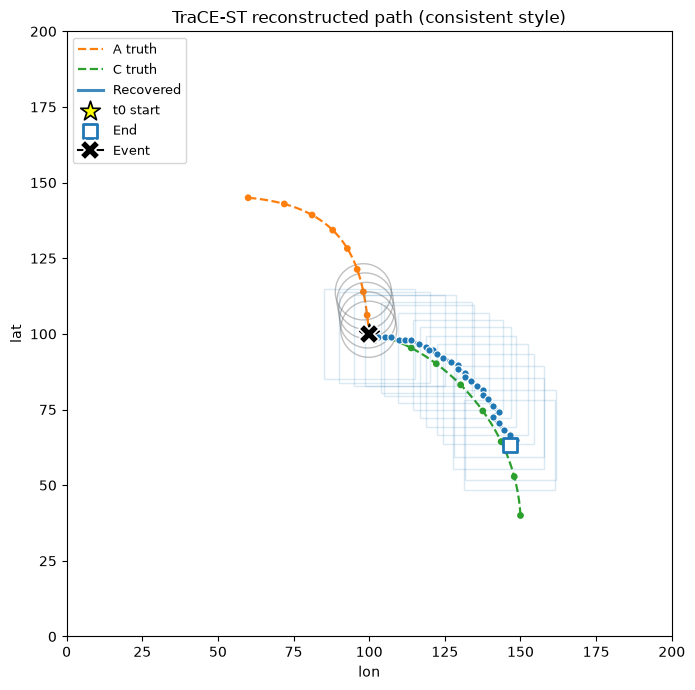

In [43]:
from matplotlib.patches import Rectangle

def add_boxes(ax, centers, box_size, color, alpha=0.14, lw=1.1, zorder=2):
    half = box_size / 2.0
    for yc, xc in centers:
        rect = Rectangle((xc - half, yc - half), box_size, box_size, fill=False, edgecolor=color, linewidth=lw, alpha=alpha, zorder=zorder)
        ax.add_patch(rect)

box_size = float(params.get('box_size', 30))
event_y, event_x = case['event']
A_clean = case.get('A_clean', None)
fig, ax = plt.subplots(figsize=(8, 7))
# plot recent contours of the A field for context
truth_times = np.arange(case['T'] - 10, case['T'], 2)
for t in truth_times:
    try:
        if A_clean is not None:
            fld = A_clean[t]
        else:
            fld = case['full_data_run'].sel(var='A').isel(time=t).values
        level = float(np.max(fld) * 0.65)
        ax.contour(case['xs'], case['ys'], fld, levels=[level], colors=['0.45'], linewidths=1.0, alpha=0.45, zorder=1)
    except Exception:
        pass
# show prescribed A/C trajectories (distinct colors)
truth_A = np.asarray(case['centers_A'])
truth_C = np.asarray(case['centers_C'])
ax.plot(truth_A[:,1], truth_A[:,0], '--', color='tab:orange', linewidth=1.6, label='A truth')
ax.scatter(truth_A[::5,1], truth_A[::5,0], s=24, color='tab:orange', edgecolor='none')
ax.plot(truth_C[:,1], truth_C[:,0], '--', color='tab:green', linewidth=1.6, label='C truth')
ax.scatter(truth_C[::5,1], truth_C[::5,0], s=24, color='tab:green', edgecolor='none')
# show recovered trajectory if available
if 'out' in globals() and out is not None:
    centers = np.asarray(out['centers'])
    add_boxes(ax, centers[::2], box_size=box_size, color='tab:blue', alpha=0.16, lw=1.0, zorder=2)
    ax.plot(centers[:,1], centers[:,0], '-', color='tab:blue', linewidth=2.2, alpha=0.85, zorder=5, label='Recovered')
    ax.scatter(centers[:,1], centers[:,0], s=28, color='tab:blue', edgecolor='white', linewidth=0.8, zorder=6)
    ax.scatter(centers[0,1], centers[0,0], marker='*', s=220, facecolor='yellow', edgecolor='black', linewidth=1.2, zorder=8, label='t0 start')
    ax.scatter(centers[-1,1], centers[-1,0], marker='s', s=110, facecolor='white', edgecolor='tab:blue', linewidth=2.0, zorder=7, label='End')
    # print parent names if present
    try:
        parent_ids = np.asarray(out.get('parents', []), dtype=int)
        parent_names = [case['full_data_run'].coords['var'].values[p-1] for p in parent_ids]
        print('Parent variable sequence:')
        print(parent_names)
    except Exception:
        pass
else:
    ax.text(0.02, 0.98, 'No reconstructed trajectory — run TraCE-ST first', transform=ax.transAxes, va='top', ha='left', fontsize=10, bbox=dict(facecolor='white', alpha=0.85), zorder=10)
# event marker
ax.plot(event_x, event_y, marker='X', markersize=14, color='black', markeredgecolor='white', markeredgewidth=1.2, zorder=9, label='Event')
ax.set_xlim(case['xs'].min(), case['xs'].max())
ax.set_ylim(case['ys'].min(), case['ys'].max())
ax.set_aspect('equal')
ax.set_title('TraCE-ST reconstructed path (consistent style)')
ax.set_xlabel('lon')
ax.set_ylabel('lat')
ax.legend(loc='upper left', frameon=True, fontsize=9)
plt.tight_layout()
plt.show()


## 7) Sample Monte Carlo pathway uncertainty

We now hold every model and scale parameter fixed and set `montecarlo=True`. At each backward step, the winning parent cluster is drawn according to the configured probability rule and cluster strengths. Repeating the trace therefore samples alternative pathways supported by the same local causal model. Spread among members represents **Monte Carlo pathway-selection uncertainty**, not parameter sensitivity.

The five members below keep the tutorial quick. Formal attribution requires a much larger ensemble to stabilize variable-specific trajectory densities and relative-contribution estimates. Parameter sensitivity should be evaluated separately by repeating such fixed-parameter Monte Carlo ensembles across physically admissible configurations.

In [44]:
# Run repeated probabilistic tracks with one fixed parameter configuration.
ensemble_results = []
n_members = 5

# Fix the random seed so this small demonstration is reproducible.
np.random.seed(42)

# Copy the deterministic configuration, changing only the selection mode.
params_ens = {**params, "cd_kwargs": dict(params["cd_kwargs"])}
params_ens["montecarlo"] = True

print(f"Running fixed-parameter Monte Carlo ensemble of {n_members} trajectories...")
for i in range(n_members):
    
    out_ens = run_track(
        case["full_data_run"],
        params_ens,
        date_end=case["date_end"],
        return_debug=True,
        return_cluster_summaries=False,
    )
    ensemble_results.append(out_ens)
    print(f"  Member {i+1}/{n_members} done: {len(out_ens['centers'])} steps")

print(f"Ensemble complete: {len(ensemble_results)} members")


Running fixed-parameter Monte Carlo ensemble of 5 trajectories...
  Member 1/5 done: 31 steps
  Member 2/5 done: 31 steps
  Member 3/5 done: 31 steps
  Member 4/5 done: 31 steps
  Member 5/5 done: 31 steps
Ensemble complete: 5 members


## 8) Visualize Monte Carlo pathway spread

Because all members use identical parameters, differences arise from probabilistic parent-cluster selection. Branching between the prescribed `A` and `C` paths is the expected expression of competing causal parents. This figure does not test how results change with `box_size`, `radius`, `timewindow`, or other parameter choices.

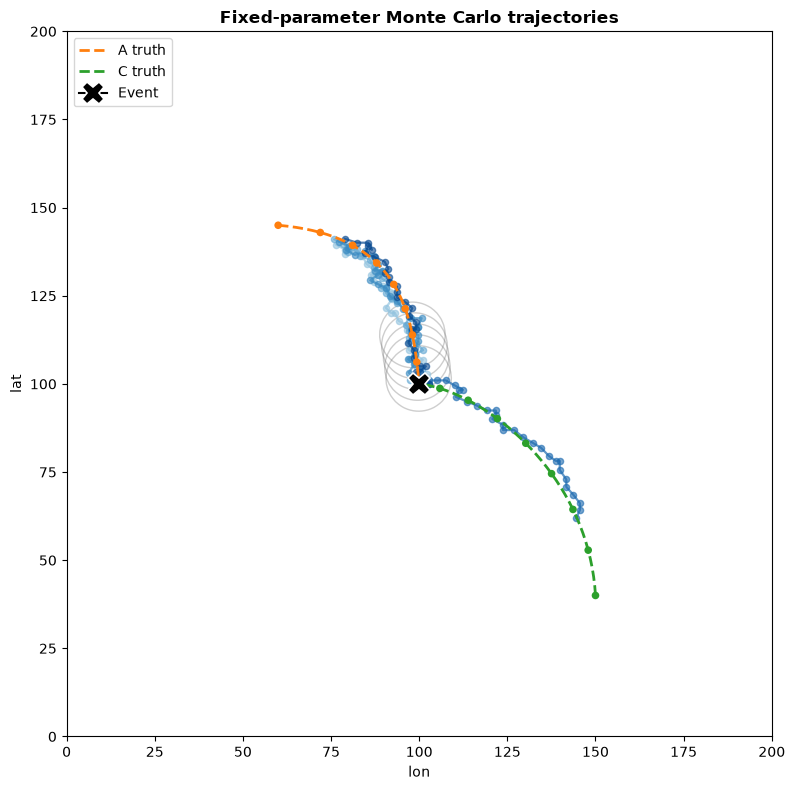

Ensemble spread: 5 trajectories plotted


In [45]:
# Ensemble visualization
fig, ax = plt.subplots(figsize=(9, 8))

# Plot background contours of A field
truth_times = np.arange(case['T'] - 10, case['T'], 2)
A_clean = case.get('A_clean', None)
for t in truth_times:
    try:
        if A_clean is not None:
            fld = A_clean[t]
        else:
            fld = case['full_data_run'].sel(var='A').isel(time=t).values
        level = float(np.max(fld) * 0.65)
        ax.contour(case['xs'], case['ys'], fld, levels=[level], colors=['0.45'], linewidths=1.0, alpha=0.35, zorder=1)
    except Exception:
        pass

# Plot truth trajectories
truth_A = np.asarray(case['centers_A'])
truth_C = np.asarray(case['centers_C'])
ax.plot(truth_A[:,1], truth_A[:,0], '--', color='tab:orange', linewidth=2.0, label='A truth', zorder=10)
ax.scatter(truth_A[::5,1], truth_A[::5,0], s=30, color='tab:orange', edgecolor='none', zorder=10)
ax.plot(truth_C[:,1], truth_C[:,0], '--', color='tab:green', linewidth=2.0, label='C truth', zorder=10)
ax.scatter(truth_C[::5,1], truth_C[::5,0], s=30, color='tab:green', edgecolor='none', zorder=10)

# Plot ensemble trajectories with different colors
ens_colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(ensemble_results)))
for i, out_ens in enumerate(ensemble_results):
    centers_ens = np.asarray(out_ens['centers'])
    ax.plot(centers_ens[:,1], centers_ens[:,0], '-', color=ens_colors[i], linewidth=1.6, alpha=0.7, zorder=5)
    ax.scatter(centers_ens[:,1], centers_ens[:,0], s=20, color=ens_colors[i], alpha=0.6, zorder=5)

# Plot event
event_y, event_x = case['event']
ax.plot(event_x, event_y, marker='X', markersize=16, color='black', markeredgecolor='white', markeredgewidth=1.2, zorder=20, label='Event')

# Styling
ax.set_xlim(case['xs'].min(), case['xs'].max())
ax.set_ylim(case['ys'].min(), case['ys'].max())
ax.set_aspect('equal')
ax.set_title('Fixed-parameter Monte Carlo trajectories', fontsize=12, fontweight='bold')
ax.set_xlabel('lon')
ax.set_ylabel('lat')
ax.legend(loc='upper left', frameon=True, fontsize=10)
plt.tight_layout()
plt.show()

print(f"Ensemble spread: {len(ensemble_results)} trajectories plotted")


## 9) Quantify ensemble consistency

We summarize three Monte Carlo diagnostics at this fixed parameter configuration: completion rate, endpoint spread, and the fraction of inferred steps assigned to each variable. These are descriptive checks for this very small tutorial ensemble. They are not substitutes for the manuscript's variable-specific spatial trajectory densities, and they do not measure parameter sensitivity.

In [46]:
# A completed N-step run contains its target center plus N backward centers.
expected_points = params["n_steps_time"] + 1
completed = [len(result["centers"]) == expected_points for result in ensemble_results]
endpoints = np.asarray([result["centers"][-1] for result in ensemble_results])

# Parent IDs are one-based; include all inferred backward parents but omit the initial target B.
parent_ids = np.concatenate([np.asarray(result["parents"])[1:] for result in ensemble_results])
var_names = np.asarray(case["full_data_run"].coords["var"].values)
parent_fractions = {
    str(name): float(np.mean(parent_ids == index))
    for index, name in enumerate(var_names, start=1)
}

print(f"Completion rate: {np.mean(completed):.0%}")
print(f"Endpoint mean (lat, lon): {endpoints.mean(axis=0)}")
print(f"Endpoint standard deviation (lat, lon): {endpoints.std(axis=0)}")
print("Fraction of traced parent steps by variable:", parent_fractions)

Completion rate: 100%
Endpoint mean (lat, lon): [124.78550677  90.6172606 ]
Endpoint standard deviation (lat, lon): [31.41543351 26.98694692]
Fraction of traced parent steps by variable: {'A': 0.7933333333333333, 'B': 0.0, 'C': 0.20666666666666667}


## Summary

This tutorial demonstrated how TraCE-ST turns a sequence of localized, one-lag causal graphs into an event-conditioned backward pathway. Because the synthetic system has known source variables, spatial paths, lag, and mixing coefficient, the reconstruction can be checked against ground truth rather than judged only by visual plausibility.

The main scientific lessons are:

1. a trajectory records both a spatial region and a selected variable at every lag;
2. a deterministic run represents one dominant inferred branch;
3. competing causal sources require probabilistic ensembles for relative-contribution estimates; and
4. Monte Carlo pathway uncertainty and sensitivity to parameter choices are distinct and should be assessed separately.

TraCE-ST remains conditional on the variables supplied, data quality, causal-discovery model, one-lag/locality assumptions, and chosen scales. The appropriate next step for a new application is therefore to define the target and admissible parameter ranges from process knowledge, run sufficiently large fixed-parameter Monte Carlo ensembles, and then repeat them as needed to characterize parameter sensitivity—not simply reuse this tutorial's numerical values.